# 📦 Encoding Categorical Data

> **Folder:** `01_Data_Preprocessing / Encoding_Categorical_Data`  
> **Notebook:** `encoding.ipynb`

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand **why** categorical encoding is necessary
- Apply **7 encoding techniques** with real examples
- Know **when to use** each technique
- Avoid common pitfalls like **data leakage** and the **dummy variable trap**

---

## 📚 Techniques Covered

| # | Technique | Use Case |
|---|-----------|----------|
| 1 | Label Encoding | Ordinal, tree-based models |
| 2 | One-Hot Encoding | Nominal, low cardinality |
| 3 | Ordinal Encoding | Explicitly ordered features |
| 4 | Binary Encoding | High cardinality |
| 5 | Frequency Encoding | High cardinality, frequency matters |
| 6 | Target Encoding (K-Fold) | High cardinality + strong target relationship |
| 7 | Hashing Encoding | Very high cardinality |


---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Optional: pip install category_encoders
try:
    from category_encoders import BinaryEncoder, HashingEncoder
    CE_AVAILABLE = True
except ImportError:
    CE_AVAILABLE = False
    print("⚠️  category_encoders not installed. Run: pip install category_encoders")

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries loaded successfully!")

⚠️  category_encoders not installed. Run: pip install category_encoders
✅ Libraries loaded successfully!


---
## 📊 1. Load & Explore Dataset

In [2]:
# ── Synthetic Dataset ────────────────────────────────────────────────────
data = {
    'Color'    : ['Red', 'Blue', 'Green', 'Blue', 'Red', 'Green', 'Blue', 'Red'],
    'Education': ['Bachelor\'s', 'PhD', 'High School', 'Master\'s', 'PhD',
                  'Bachelor\'s', 'High School', 'Master\'s'],
    'City'     : ['London', 'Paris', 'Berlin', 'London', 'Paris',
                  'Berlin', 'London', 'Paris'],
    'Gender'   : ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Price'    : [250, 400, 150, 300, 420, 180, 310, 390],
    'Target'   : [1, 0, 1, 0, 0, 1, 1, 0],
}

df = pd.DataFrame(data)
print(f'Shape: {df.shape}')
df

Shape: (8, 6)


,Color,Education,City,Gender,Price,Target
0,Red,Bachelor's,London,Male,250,1
1,Blue,PhD,Paris,Female,400,0
2,Green,High School,Berlin,Male,150,1
3,Blue,Master's,London,Female,300,0
4,Red,PhD,Paris,Male,420,0
5,Green,Bachelor's,Berlin,Female,180,1
6,Blue,High School,London,Male,310,1
7,Red,Master's,Paris,Female,390,0


In [3]:
# ── Data Types & Cardinality ─────────────────────────────────────────────
print('Data Types:')
print(df.dtypes)
print()

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical Columns:', cat_cols)

cardinality = pd.DataFrame({
    'Column'       : cat_cols,
    'Unique Values': [df[c].nunique() for c in cat_cols],
    'Sample Values': [df[c].unique().tolist() for c in cat_cols]
})
cardinality

Data Types:
Color        object
Education    object
City         object
Gender       object
Price         int64
Target        int64
dtype: object

Categorical Columns: ['Color', 'Education', 'City', 'Gender']


,Column,Unique Values,Sample Values
0,Color,3,"[Red, Blue, Green]"
1,Education,4,"[Bachelor's, PhD, High School, Master's]"
2,City,3,"[London, Paris, Berlin]"
3,Gender,2,"[Male, Female]"


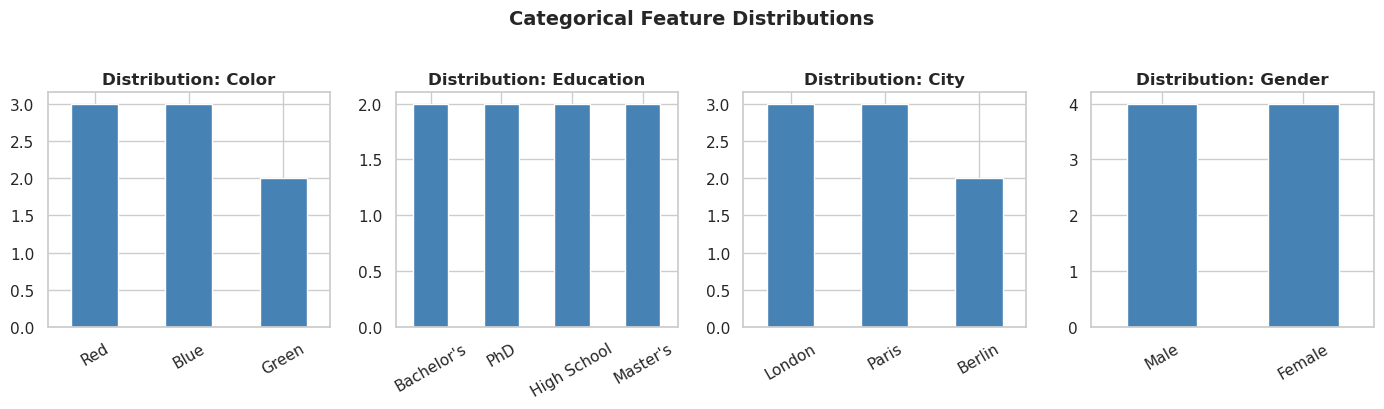

In [4]:
# ── Visualize Category Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 4))

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 1️⃣ Label Encoding

> Assigns an integer to each category. Best for **ordinal features** or **tree-based models**.
>
> ⚠️ Avoid for nominal data with linear models — implies false ordering.

In [5]:
df_label = df.copy()
le = LabelEncoder()

for col in ['Color', 'Gender']:
    df_label[col] = le.fit_transform(df_label[col])
    print(f"'{col}' mapping: { {k: v for v, k in enumerate(le.classes_)} }")

df_label[['Color', 'Gender']]

'Color' mapping: {'Blue': 0, 'Green': 1, 'Red': 2}
'Gender' mapping: {'Female': 0, 'Male': 1}


,Color,Gender
0,2,1
1,0,0
2,1,1
3,0,0
4,2,1
5,1,0
6,0,1
7,2,0


---
## 2️⃣ One-Hot Encoding (OHE)

> Creates a **binary column per category**. Best for **nominal, low-cardinality** features.
>
> ⚠️ Use `drop_first=True` to avoid the **dummy variable trap**.

In [6]:
# ── pandas get_dummies ──────────────────────────────────────────────────
df_ohe = pd.get_dummies(df.copy(), columns=['Color'], drop_first=True, dtype=int)
print(f'Shape after OHE: {df_ohe.shape}')
df_ohe

Shape after OHE: (8, 7)


,Education,City,Gender,Price,Target,Color_Green,Color_Red
0,Bachelor's,London,Male,250,1,0,1
1,PhD,Paris,Female,400,0,0,0
2,High School,Berlin,Male,150,1,1,0
3,Master's,London,Female,300,0,0,0
4,PhD,Paris,Male,420,0,0,1
5,Bachelor's,Berlin,Female,180,1,1,0
6,High School,London,Male,310,1,0,0
7,Master's,Paris,Female,390,0,0,1


In [7]:
# ── sklearn OneHotEncoder (fit on train, transform test) ─────────────────
X = df[['Color', 'Price']].copy()
y = df['Target']

X_train, X_test = train_test_split(X, test_size=0.25, random_state=42)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
train_encoded = encoder.fit_transform(X_train[['Color']])
test_encoded  = encoder.transform(X_test[['Color']])

feature_names = encoder.get_feature_names_out(['Color'])

X_train_ohe = X_train.drop(columns=['Color']).join(
    pd.DataFrame(train_encoded, columns=feature_names, index=X_train.index)
)
X_test_ohe = X_test.drop(columns=['Color']).join(
    pd.DataFrame(test_encoded, columns=feature_names, index=X_test.index)
)

print('Train set:')
print(X_train_ohe)
print('\nTest set:')
print(X_test_ohe)

Train set:
   Price  Color_Green  Color_Red
0    250          0.0        1.0
7    390          0.0        1.0
2    150          1.0        0.0
4    420          0.0        1.0
3    300          0.0        0.0
6    310          0.0        0.0

Test set:
   Price  Color_Green  Color_Red
1    400          0.0        0.0
5    180          1.0        0.0


---
## 3️⃣ Ordinal Encoding

> Manually maps **ordered categories** to integers. Preserves rank information.

In [8]:
edu_order = ['High School', "Bachelor's", "Master's", 'PhD']

df_ord = df.copy()
encoder = OrdinalEncoder(categories=[edu_order])
df_ord['Education'] = encoder.fit_transform(df_ord[['Education']])

print('Ordinal Mapping:')
for i, cat in enumerate(edu_order):
    print(f'  {cat:15s} → {i}')

df_ord[['Education']]

Ordinal Mapping:
  High School     → 0
  Bachelor's      → 1
  Master's        → 2
  PhD             → 3


,Education
0,1.0
1,3.0
2,0.0
3,2.0
4,3.0
5,1.0
6,0.0
7,2.0


---
## 4️⃣ Binary Encoding

> Converts categories to **binary representation**. More compact than OHE for high-cardinality features.
>
> Requires: `pip install category_encoders`

In [9]:
if CE_AVAILABLE:
    X_tr = df[['City', 'Price']].iloc[:6]
    X_te = df[['City', 'Price']].iloc[6:]

    enc = BinaryEncoder(cols=['City'])
    X_tr_bin = enc.fit_transform(X_tr)
    X_te_bin = enc.transform(X_te)

    print('Train (Binary Encoded):')
    print(X_tr_bin)
else:
    print('⚠️  Install category_encoders: pip install category_encoders')

⚠️  Install category_encoders: pip install category_encoders


---
## 5️⃣ Frequency / Count Encoding

> Replaces each category with its **count in the dataset**. Useful when frequency relates to target.

In [10]:
df_freq = df.copy()
freq_map = df_freq['City'].value_counts().to_dict()
df_freq['City_freq'] = df_freq['City'].map(freq_map)

print('Frequency Map:', freq_map)
df_freq[['City', 'City_freq']]

Frequency Map: {'London': 3, 'Paris': 3, 'Berlin': 2}


,City,City_freq
0,London,3
1,Paris,3
2,Berlin,2
3,London,3
4,Paris,3
5,Berlin,2
6,London,3
7,Paris,3


---
## 6️⃣ Target Encoding (K-Fold — No Leakage)

> Replaces categories with the **mean of the target** for that category.
>
> ⚠️ Always apply within **K-Fold CV** to prevent data leakage!

In [11]:
df_target = df.copy()
df_target['City_target_enc'] = np.nan

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(df_target):
    train_fold = df_target.iloc[train_idx]
    mean_map   = train_fold.groupby('City')['Target'].mean()
    df_target.iloc[val_idx, df_target.columns.get_loc('City_target_enc')] = (
        df_target.iloc[val_idx]['City'].map(mean_map)
    )

# Fill unseen categories with global mean
global_mean = df_target['Target'].mean()
df_target['City_target_enc'] = df_target['City_target_enc'].fillna(global_mean)

df_target[['City', 'City_target_enc', 'Target']]

,City,City_target_enc,Target
0,London,0.5,1
1,Paris,0.0,0
2,Berlin,1.0,1
3,London,1.0,0
4,Paris,0.0,0
5,Berlin,1.0,1
6,London,1.0,1
7,Paris,0.0,0


---
## 7️⃣ Hashing Encoding

> Uses a **hash function** to map categories to a fixed number of columns. Ideal for very high cardinality.

In [12]:
if CE_AVAILABLE:
    X_hash = df[['City', 'Price']]
    enc_hash = HashingEncoder(cols=['City'], n_components=4)
    X_hashed = enc_hash.fit_transform(X_hash)

    print('Hashed Features:')
    print(X_hashed)
else:
    print('⚠️  Install category_encoders: pip install category_encoders')

⚠️  Install category_encoders: pip install category_encoders


---
## 📊 8. Encoding Comparison — Impact on Model

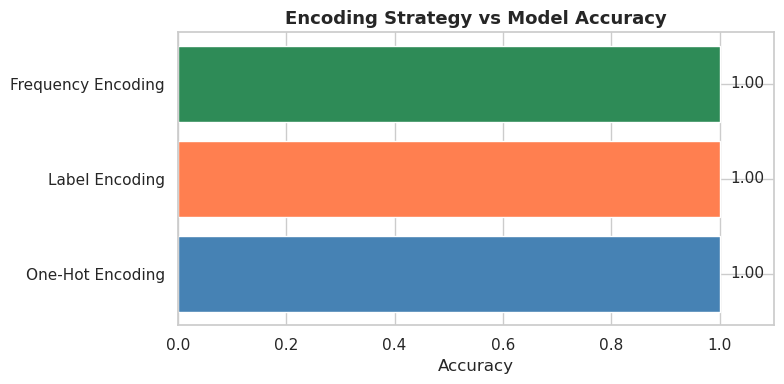


📊 Results:
  One-Hot Encoding         : 1.0000
  Label Encoding           : 1.0000
  Frequency Encoding       : 1.0000


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

results = {}

# ── OHE ─────────────────────────────────────────────────────────────────
X_ohe = pd.get_dummies(df[['Color', 'City', 'Price']], drop_first=True, dtype=int)
y_all = df['Target']
X_tr, X_te, y_tr, y_te = train_test_split(X_ohe, y_all, test_size=0.25, random_state=42)
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_tr, y_tr)
results['One-Hot Encoding'] = accuracy_score(y_te, clf.predict(X_te))

# ── Label Encoding ───────────────────────────────────────────────────────
X_lbl = df[['Color', 'City', 'Price']].copy()
for col in ['Color', 'City']:
    X_lbl[col] = LabelEncoder().fit_transform(X_lbl[col])
X_tr, X_te, y_tr, y_te = train_test_split(X_lbl, y_all, test_size=0.25, random_state=42)
clf.fit(X_tr, y_tr)
results['Label Encoding'] = accuracy_score(y_te, clf.predict(X_te))

# ── Frequency Encoding ───────────────────────────────────────────────────
X_frq = df[['Color', 'City', 'Price']].copy()
for col in ['Color', 'City']:
    X_frq[col] = X_frq[col].map(X_frq[col].value_counts())
X_tr, X_te, y_tr, y_te = train_test_split(X_frq, y_all, test_size=0.25, random_state=42)
clf.fit(X_tr, y_tr)
results['Frequency Encoding'] = accuracy_score(y_te, clf.predict(X_te))

# ── Plot Results ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(results.keys()), list(results.values()),
               color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
ax.set_xlim(0, 1.1)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Encoding Strategy vs Model Accuracy', fontsize=13, fontweight='bold')

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print('\n📊 Results:')
for method, acc in results.items():
    print(f'  {method:25s}: {acc:.4f}')

---
## ✅ 9. Summary & Best Practices

| Technique | When to Use | Risk |
|-----------|-------------|------|
| **Label Encoding** | Ordinal + tree models | False ordering on nominal |
| **One-Hot Encoding** | Nominal + linear models | Dummy trap, dimensionality |
| **Ordinal Encoding** | Ordered categories | Requires known order |
| **Binary Encoding** | High cardinality | Needs category_encoders |
| **Frequency Encoding** | High cardinality | Ties collapse distinct categories |
| **Target Encoding** | High card + strong signal | Data leakage without CV |
| **Hashing Encoding** | Very high cardinality | Hash collisions |

### 🔑 Golden Rules

1. **Always fit encoders on train set only** — never on the full data
2. **Use `drop_first=True` with OHE** — avoid the dummy variable trap
3. **Use K-Fold with Target Encoding** — prevent leakage
4. **Check cardinality first** — choose technique accordingly
5. **Handle unseen categories** in test with `handle_unknown='ignore'`

---

## 🔗 Next Steps

- ➡️ `Feature_Scaling/` — Scale encoded numeric features
- ➡️ `Handling_Missing_Values/` — Fill nulls before encoding
- ➡️ `03_Supervised_Learning/` — Apply encodings in full ML pipelines